(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicates: 0


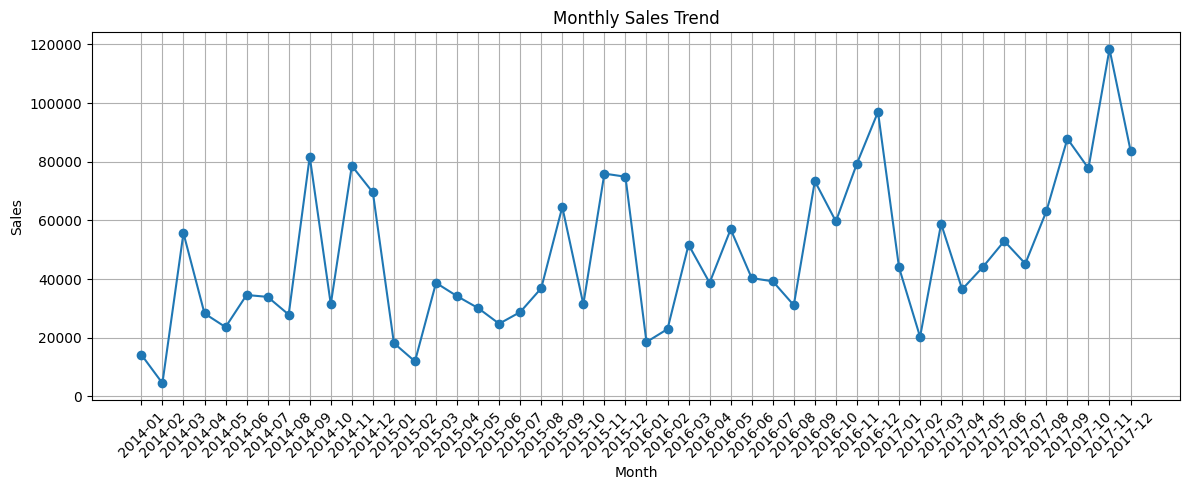

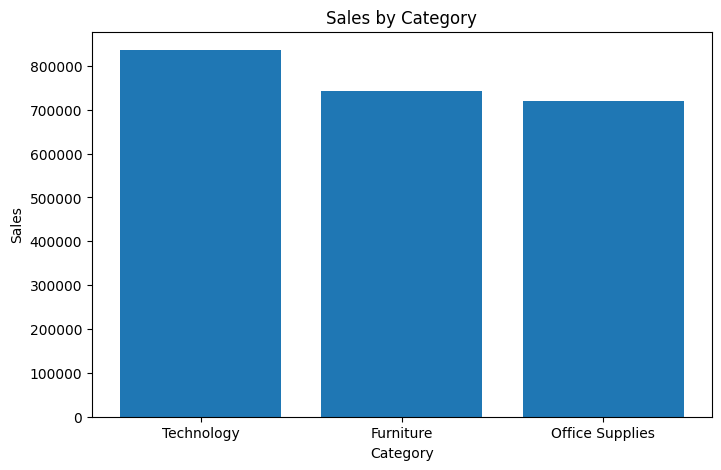

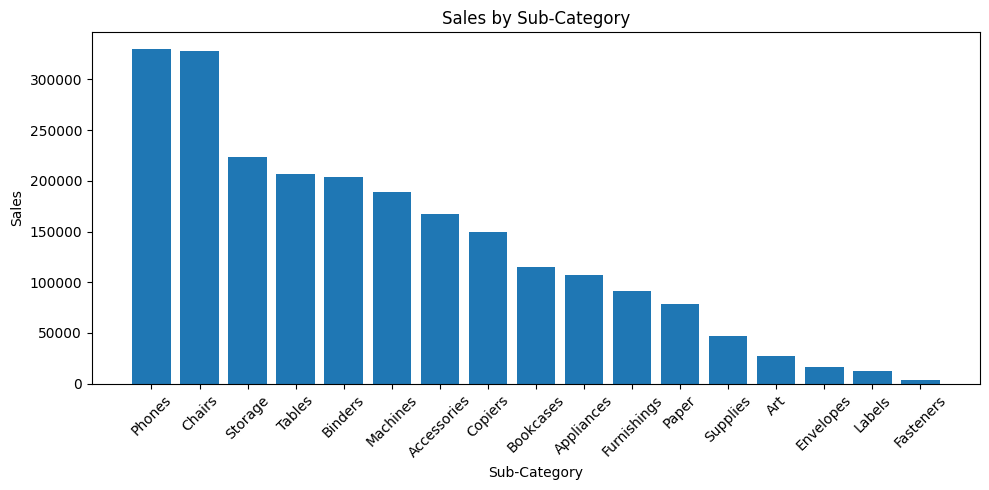

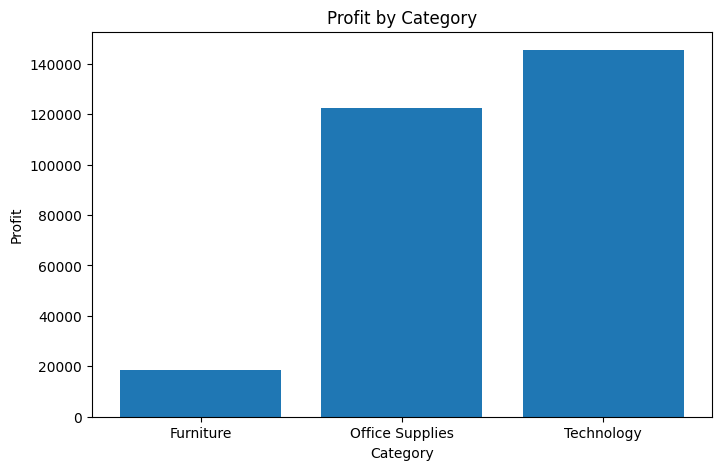

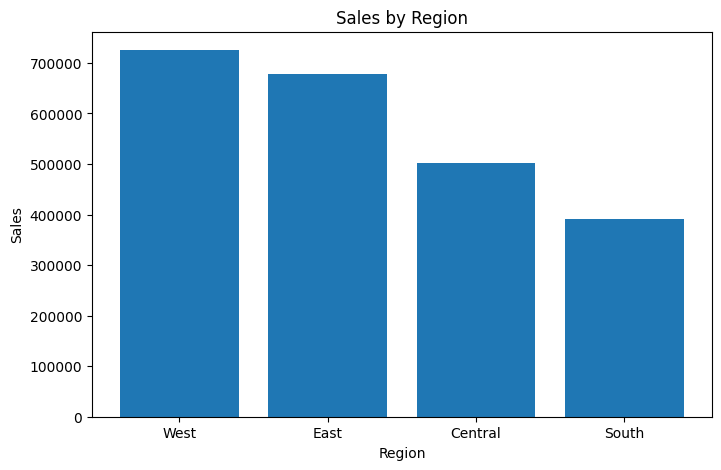

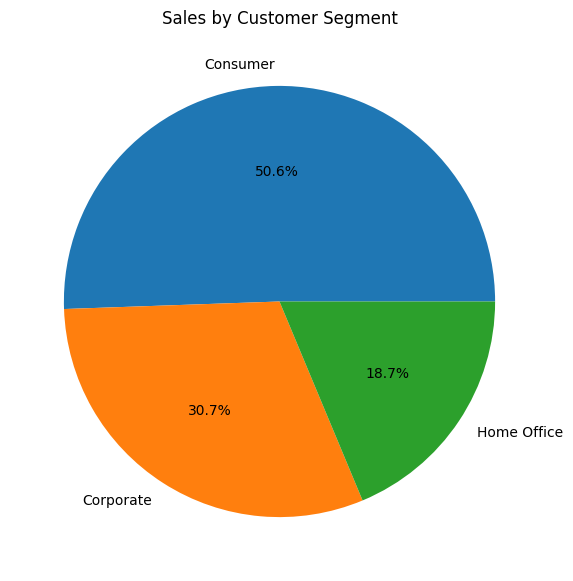

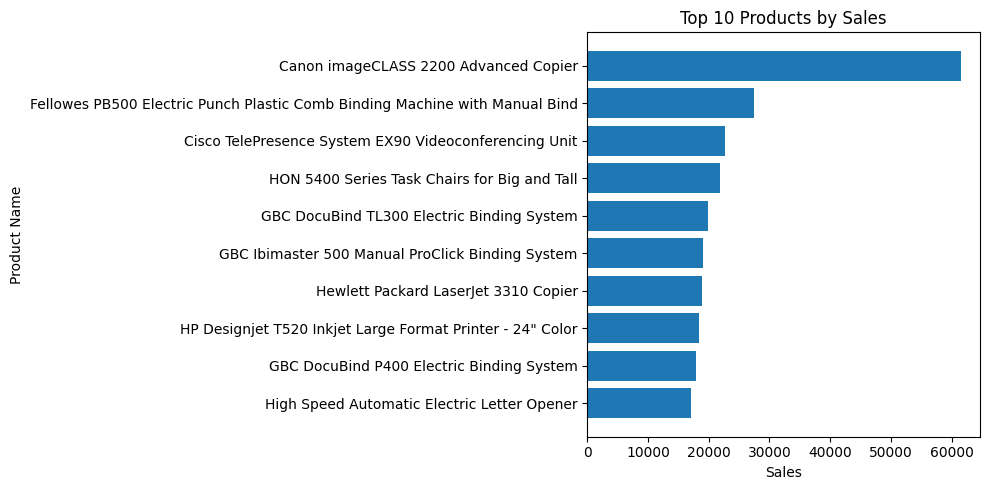

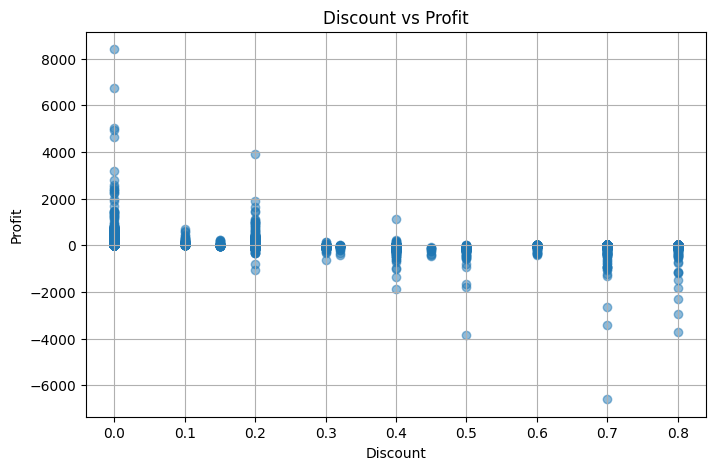

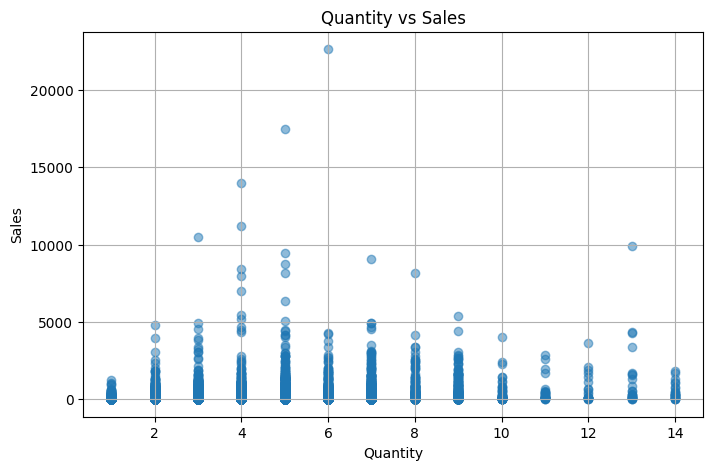

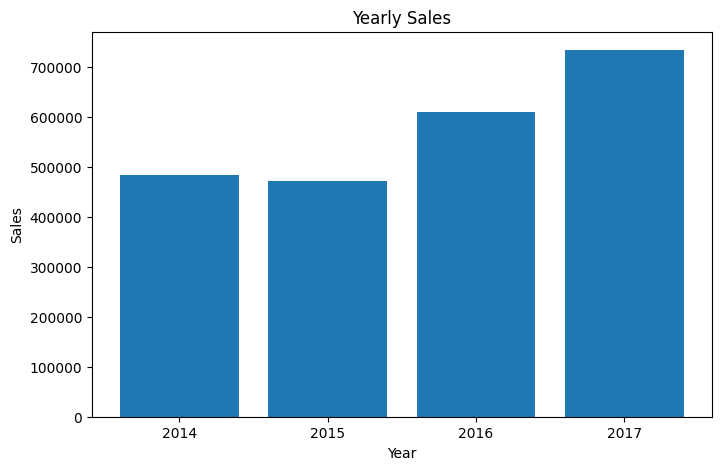

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Top Category: Technology
Top Region: West
Top Product: Canon imageCLASS 2200 Advanced Copier
Cleaned dataset saved successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("e commerce dataset (1).csv", encoding="latin1")

print(df.shape)
display(df.head())

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

# 1. Monthly Sales
monthly = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# 2. Category Sales
category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(category.index, category.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# 3. Sub-Category Sales
subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(subcategory.index, subcategory.values)
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Profit by Category
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

# 5. Regional Sales
region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region.index, region.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# 6. Segment Sales
segment = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,7))
plt.pie(segment.values, labels=segment.index, autopct="%1.1f%%")
plt.title("Sales by Customer Segment")
plt.show()

# 7. Top 10 Products
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_products.index[::-1], top_products.values[::-1])
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

# 8. Discount vs Profit
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid()
plt.show()

# 9. Quantity vs Sales
plt.figure(figsize=(8,5))
plt.scatter(df["Quantity"], df["Sales"], alpha=0.5)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.grid()
plt.show()

# 10. Yearly Sales
yearly = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(yearly.index.astype(str), yearly.values)
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity:", df["Quantity"].sum())
print("Top Category:", category.index[0])
print("Top Region:", region.index[0])
print("Top Product:", top_products.index[0])

df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")